# Figure 4: Comparative Data + Two Photeros Points

This notebook is a simplified comparative plot. It includes:
- Literature comparative points (Stoddard & Salazar 2011 table)
- Two Photeros points that differ only in resting RMR (day and night)

In [19]:
from functools import lru_cache
from pathlib import Path
import re
import xml.etree.ElementTree as ET

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.path import Path as MplPath

# Optional icon support for the icon-based plot.
try:
    from svgpath2mpl import parse_path
except ImportError as exc:
    raise ImportError(
        "Install svgpath2mpl to render icon markers (conda install -c conda-forge svgpath2mpl)."
    ) from exc

plt.rcParams['font.family'] = 'Avenir'

# Literature compilation (Stoddard & Salazar 2011 Table 1).
lit_path = Path('../data/stoddard_salazar_2011_table1.csv')
lit = pd.read_csv(lit_path, dtype={'sp_no': str})
lit = lit.rename(columns={'V_O2_resting': 'rest_rate', 'V_O2_signal': 'signal_rate'})

# Photeros points (observed).
photeros_day_rest = 1.181223
photeros_night_rest = 2.097811
photeros_signal_observed = 5.844194

# Unit-aware labels for axes and legend entries.
rate_units = 'µL $O_2$/mg/hr'
x_label = f'Resting metabolic rate ({rate_units})'
y_label = f'Signal-associated metabolic rate \n({rate_units})'
legend_day = 'Photeros (day resting RMR)'
legend_night = 'Photeros (night resting RMR)'

# Local icon files used in icon-based plot.
ICON_DIR = Path('icons')
icon_paths = {
    'spider': ICON_DIR / 'spider.svg',
    'insect': ICON_DIR / 'insect.svg',
    'fish': ICON_DIR / 'fish.svg',
    'frog': ICON_DIR / 'frog.svg',
    'bird': ICON_DIR / 'bird.svg',
}
icon_sizes = {
    'spider': 250,
    'insect': 140,
    'fish': 550,
    'frog': 300,
    'bird': 210,
}

# Plot toggles.
USE_ICONS = False
SHOW_POINT_NUMBERS = False

def draw_reference_lines(ax, xmin=0.05, xmax=5.0):
    xline = np.logspace(np.log10(xmin), np.log10(xmax), 300)
    for exponent in range(-2, 4):
        factor = np.exp(exponent)
        ax.plot(xline, factor * xline, lw=0.8, alpha=0.14, color='0.65', zorder=0)
    ax.plot(xline, xline, lw=1.0, color='0.35', zorder=1)

def parse_svg_transform(transform_str):
    matrix = np.eye(3, dtype=float)
    if not transform_str:
        return matrix

    for name, args in re.findall(r'([a-zA-Z]+)\(([^)]*)\)', transform_str):
        values = [float(v) for v in re.split(r'[ ,]+', args.strip()) if v]
        if name == 'translate':
            tx = values[0] if values else 0.0
            ty = values[1] if len(values) > 1 else 0.0
            t = np.array([[1.0, 0.0, tx], [0.0, 1.0, ty], [0.0, 0.0, 1.0]])
        elif name == 'scale':
            sx = values[0] if values else 1.0
            sy = values[1] if len(values) > 1 else sx
            t = np.array([[sx, 0.0, 0.0], [0.0, sy, 0.0], [0.0, 0.0, 1.0]])
        elif name == 'matrix' and len(values) == 6:
            a, b, c, d, e, f = values
            t = np.array([[a, c, e], [b, d, f], [0.0, 0.0, 1.0]])
        else:
            continue
        matrix = matrix @ t
    return matrix

def transform_path(path_obj, matrix):
    verts = path_obj.vertices
    hom = np.column_stack([verts, np.ones(len(verts))])
    transformed = hom @ matrix.T
    return MplPath(transformed[:, :2], path_obj.codes)

@lru_cache(maxsize=None)
def load_svg_icon(path_str):
    path = Path(path_str)
    if not path.exists():
        return None

    root = ET.parse(path).getroot()
    group_matrix = np.eye(3, dtype=float)
    for element in root.iter():
        if element.tag.endswith('g') and element.attrib.get('transform'):
            group_matrix = parse_svg_transform(element.attrib['transform'])
            break

    svg_paths = []
    for element in root.iter():
        if element.tag.endswith('path') and element.attrib.get('d'):
            raw_path = parse_path(element.attrib['d'])
            svg_paths.append(transform_path(raw_path, group_matrix))

    if not svg_paths:
        return None

    compound = MplPath.make_compound_path(*svg_paths)
    verts = compound.vertices
    finite = np.isfinite(verts).all(axis=1)
    if not finite.any():
        return None

    x0, y0 = verts[finite].min(axis=0)
    x1, y1 = verts[finite].max(axis=0)
    height = max(y1 - y0, 1e-9)
    center = np.array([(x0 + x1) / 2.0, (y0 + y1) / 2.0])

    normalized = (compound.vertices.copy() - center) / height
    normalized[:, 1] *= -1.0
    return MplPath(normalized, compound.codes)

def add_icon(ax, x, y, group, size=None, color='black', alpha=1.0):
    icon_path = load_svg_icon(str(icon_paths[group]))
    if icon_path is None:
        return False
    ax.scatter(
        [x], [y],
        marker=icon_path,
        s=icon_sizes[group] if size is None else size,
        c=color,
        alpha=alpha,
        linewidths=0,
        zorder=3,
    )
    return True

print('Loaded comparative rows:', len(lit))
print('Use icons for literature points:', USE_ICONS)
print('Show point numbers:', SHOW_POINT_NUMBERS)
print('Photeros day point:', photeros_day_rest, photeros_signal_observed)
print('Photeros night point:', photeros_night_rest, photeros_signal_observed)

Loaded comparative rows: 25
Use icons for literature points: False
Show point numbers: False
Photeros day point: 1.181223 5.844194
Photeros night point: 2.097811 5.844194


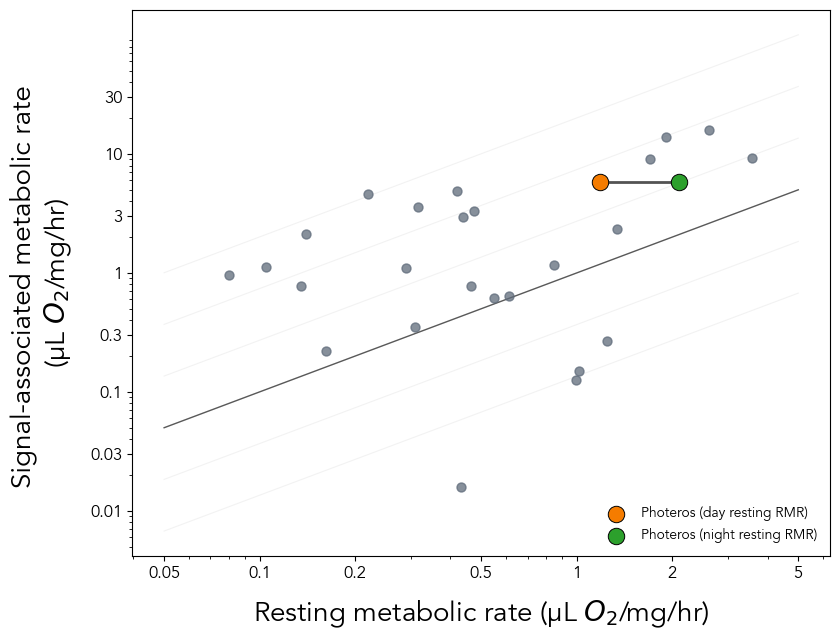

In [20]:
fig, ax = plt.subplots(figsize=(8.5, 6.5))

draw_reference_lines(ax, xmin=0.05, xmax=5.0)

# Literature plotted as circles by default; set USE_ICONS=True in Cell 2 to use icons.
for _, row in lit.iterrows():
    x = row['rest_rate']
    y = row['signal_rate']
    group = row.get('group', None)

    used_icon = False
    if USE_ICONS and group in icon_paths:
        used_icon = add_icon(ax, x, y, group=group)

    if not used_icon:
        ax.scatter([x], [y], marker='o', s=42, color='#5f6b7a', alpha=0.75, zorder=2)

    if SHOW_POINT_NUMBERS:
        ax.annotate(
            str(row['sp_no']),
            (x, y),
            xytext=(5, 4),
            textcoords='offset points',
            fontsize=8,
            alpha=0.8,
        )

# Connect the two Photeros estimates so they read as one linked estimate pair.
ax.plot(
    [photeros_day_rest, photeros_night_rest],
    [photeros_signal_observed, photeros_signal_observed],
    color='0.25',
    linewidth=2.0,
    alpha=0.9,
    zorder=4,
    )

# Two observed Photeros points with different resting RMR values (non-star markers).
ax.scatter(
    [photeros_day_rest], [photeros_signal_observed],
    marker='o', s=140, color='#f57c00', edgecolor='black', linewidth=0.7,
    label=legend_day,
    zorder=5,
    )
ax.scatter(
    [photeros_night_rest], [photeros_signal_observed],
    marker='o', s=140, color='#2ca02c', edgecolor='black', linewidth=0.7,
    label=legend_night,
    zorder=5,
    )

ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel(x_label, fontsize=20, labelpad=12)
ax.set_ylabel(y_label, fontsize=20, labelpad=12)
ax.tick_params(axis='both', labelsize=12)

ax.set_xticks([0.05, 0.1, 0.2, 0.5, 1, 2, 5])
ax.set_xticklabels(['0.05', '0.1', '0.2', '0.5', '1', '2', '5'])
ax.set_yticks([0.01, 0.03, 0.1, 0.3, 1, 3, 10, 30])
ax.set_yticklabels(['0.01', '0.03', '0.1', '0.3', '1', '3', '10', '30'])

ax.legend(frameon=False, loc='lower right', fontsize=10)
plt.tight_layout()
plt.show()

## Add newer data from literature search

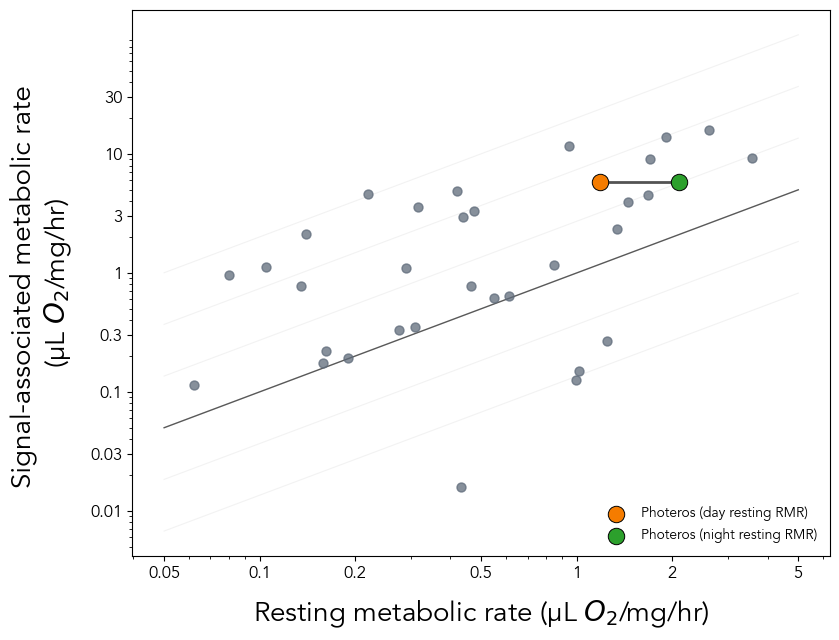

Baseline rows: 25
Added update rows: 7
Combined comparative rows: 32


In [21]:
# Combine baseline literature table with new rows (25-31) and plot with same style.
update_path = Path('../data/salazar_format_update_rows_25_31.csv')
if not update_path.exists():
    raise FileNotFoundError(f'Could not find update file: {update_path}')

update_df = pd.read_csv(update_path, dtype={'sp_no': str})
update_df = update_df.rename(columns={'V_O2_resting': 'rest_rate', 'V_O2_signal': 'signal_rate'})

# Keep expected plotting columns if present.
keep_cols = [
    'sp_no', 'group', 'species', 'common_name', 'signal_type',
    'rest_rate', 'signal_rate', 'signal_factorial_scope', 'original_ref', 'secondary_ref'
]
existing_keep = [c for c in keep_cols if c in update_df.columns]
update_df = update_df[existing_keep].copy()

# Combine and prefer updated rows if sp_no overlaps.
combined_lit = pd.concat([lit, update_df], ignore_index=True)
if 'sp_no' in combined_lit.columns:
    combined_lit = combined_lit.drop_duplicates(subset=['sp_no'], keep='last')

# Sort by species number where possible.
combined_lit['_sp_num'] = pd.to_numeric(combined_lit['sp_no'], errors='coerce')
combined_lit = combined_lit.sort_values(['_sp_num', 'sp_no']).drop(columns=['_sp_num'])

fig, ax = plt.subplots(figsize=(8.5, 6.5))

draw_reference_lines(ax, xmin=0.05, xmax=5.0)

# Literature plotted as circles by default; set USE_ICONS=True in Cell 2 to use icons.
for _, row in combined_lit.iterrows():
    x = row['rest_rate']
    y = row['signal_rate']
    group = row.get('group', None)

    used_icon = False
    if USE_ICONS and group in icon_paths:
        used_icon = add_icon(ax, x, y, group=group)

    if not used_icon:
        ax.scatter([x], [y], marker='o', s=42, color='#5f6b7a', alpha=0.75, zorder=2)

    if SHOW_POINT_NUMBERS:
        ax.annotate(
            str(row['sp_no']),
            (x, y),
            xytext=(5, 4),
            textcoords='offset points',
            fontsize=8,
            alpha=0.8,
        )

# Connect the two Photeros estimates so they read as one linked estimate pair.
ax.plot(
    [photeros_day_rest, photeros_night_rest],
    [photeros_signal_observed, photeros_signal_observed],
    color='0.25',
    linewidth=2.0,
    alpha=0.9,
    zorder=4,
)

# Two observed Photeros points with different resting RMR values.
ax.scatter(
    [photeros_day_rest], [photeros_signal_observed],
    marker='o', s=140, color='#f57c00', edgecolor='black', linewidth=0.7,
    label=legend_day,
    zorder=5,
)
ax.scatter(
    [photeros_night_rest], [photeros_signal_observed],
    marker='o', s=140, color='#2ca02c', edgecolor='black', linewidth=0.7,
    label=legend_night,
    zorder=5,
)

ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel(x_label, fontsize=20, labelpad=12)
ax.set_ylabel(y_label, fontsize=20, labelpad=12)
ax.tick_params(axis='both', labelsize=12)

ax.set_xticks([0.05, 0.1, 0.2, 0.5, 1, 2, 5])
ax.set_xticklabels(['0.05', '0.1', '0.2', '0.5', '1', '2', '5'])
ax.set_yticks([0.01, 0.03, 0.1, 0.3, 1, 3, 10, 30])
ax.set_yticklabels(['0.01', '0.03', '0.1', '0.3', '1', '3', '10', '30'])

ax.legend(frameon=False, loc='lower right', fontsize=10)
plt.tight_layout()
plt.show()

print('Baseline rows:', len(lit))
print('Added update rows:', len(update_df))
print('Combined comparative rows:', len(combined_lit))